# MAP — Charting Student Math Misunderstandings
## ModernBERT & Ettin Encoder 系列比較


本 notebook 涵蓋完整 pipeline：資料探索 → 模型設計 → 訓練設定 → 結果分析 → Submission 生成。

---

### 研究設計：三模型 L 型對照實驗

本實驗部署三個模型，形成兩個正交的受控比較——同時隔離 scale 與 architecture 兩個效應：

```
  MB-base (150M) ──── Scale Effect (+0.214) ────→ MB-large (395M)
                                        │
                                    Architecture Effect
                                      (+0.017)
                                        │
                                        ↓
                                    Ettin-400m (400M)
```

- **縱向（Scale 效應）**：ModernBERT-base → ModernBERT-large，固定架構，2.6× 參數量放大
- **橫向（Architecture 效應）**：ModernBERT-large vs Ettin-400m，參數量相近（395M vs 400M）、預訓練資料量相同（均 2T tokens）

---

## 實驗模型（3 個）

| 模型 | Hugging Face ID | 參數量 | 架構類型 |
|------|----------------|--------|---------|
| ModernBERT-base | answerdotai/ModernBERT-base | ~150M | ModernBERT（RoPE + alternating attention） |
| ModernBERT-large | answerdotai/ModernBERT-large | ~395M | ModernBERT（同上，更大） |
| Ettin-encoder-400m | jhu-clsp/ettin-encoder-400m | ~400M | Bidirectional Ettin（bilinear attention） |

### 訓練環境

| 項目 | 規格 |
|------|------|
| GPU | 2× NVIDIA GeForce RTX 3090（各 25.8 GB，Ampere sm86） |
| 並行 | HuggingFace Trainer DataParallel（effective batch = per-GPU batch × 2） |
| 精度 | bfloat16（Ampere 原生支援） + tf32 矩陣加速 |
| Attention | sdpa（PyTorch 原生 scaled dot-product attention） |
| Framework | PyTorch 2.11.0+cu128 / transformers 5.6.2 / datasets 4.8.5 |

## 1. 環境設定

自動偵測執行環境（本機 / Kaggle），設定 `DATA_DIR`（資料來源）與 `RESULTS_DIR`（checkpoint、log、submission 輸出位置）。

In [ ]:
import os, sys, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 自動偵測執行環境 ──────────────────────────────────────────
ON_KAGGLE = Path("/kaggle/input").exists()

if ON_KAGGLE:
    candidates = list(Path("/kaggle/input").rglob("train.csv"))
    if not candidates:
        raise FileNotFoundError("找不到 train.csv！請在右側 Add data 加入競賽資料集。")
    DATA_DIR = candidates[0].parent
    RESULTS_DIR = Path("/kaggle/working/results")
else:
    DATA_DIR = Path(r"C:\Users\csie\Downloads\期末報告\期末報告\map-charting-student-math-misunderstandings\map-charting-student-math-misunderstandings")
    RESULTS_DIR = Path(r"C:\Users\csie\Downloads\期末報告\期末報告\results")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"環境    : {'Kaggle' if ON_KAGGLE else '本機'}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"RESULTS : {RESULTS_DIR}")
print(f"Python  : {sys.version.split()[0]}")

In [ ]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {props.name}  {props.total_memory/1e9:.1f} GB")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU 0: NVIDIA GeForce RTX 3090 (23 GB)
GPU 1: NVIDIA GeForce RTX 3090 (23 GB)
ON_KAGGLE: False


## 2. 資料探索 (EDA)

In [ ]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

print(f"train shape: {train_df.shape}")
print(f"test  shape: {test_df.shape}")
train_df.head(3)

train shape: (36696, 7)
test  shape: (3, 5)


,row_id,QuestionId,QuestionText,MC_Answer,StudentExplanation,Category,Misconception
0,0,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),0ne third is equal to tree nineth,True_Correct,NaN
1,1,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),1 / 3 because 6 over 9 is 2 thirds and 1 third...,True_Correct,NaN
2,2,31772,What fraction of the shape is not shaded? Give...,\( \frac{1}{3} \),"1 3rd is half of 3 6th, so it is simplee to un...",True_Neither,NaN


In [ ]:
train_df["label_str"] = train_df["Category"] + ":" + train_df["Misconception"].fillna("NA")

print("Category 種類:", train_df["Category"].nunique(), sorted(train_df["Category"].unique()))
print("Misconception 種類 (含NA):", train_df["Misconception"].fillna("NA").nunique())
print("label_str 種類:", train_df["label_str"].nunique())

Category 種類: 6 ['False_Correct', 'False_Misconception', 'False_Neither', 'True_Correct', 'True_Misconception', 'True_Neither']
Misconception 種類 (含NA): 36
label_str 種類: 65


最多：True_Correct:NA  (14802 筆)
最少：True_Misconception:Base_rate  (1 筆)
中位數：50 筆


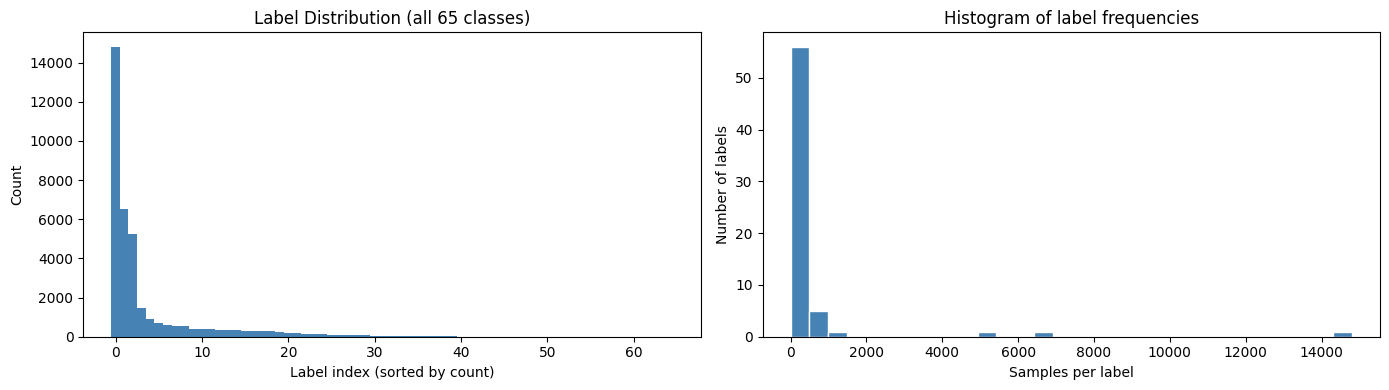

In [ ]:
label_counts = train_df["label_str"].value_counts()
print(f"最多：{label_counts.index[0]}  ({label_counts.iloc[0]} 筆)")
print(f"最少：{label_counts.index[-1]}  ({label_counts.iloc[-1]} 筆)")
print(f"中位數：{label_counts.median():.0f} 筆")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(len(label_counts)), label_counts.values, width=1.0, color="steelblue")
axes[0].set_xlabel("Label index (sorted by count)")
axes[0].set_ylabel("Count")
axes[0].set_title("Label Distribution (all 65 classes)")

axes[1].hist(label_counts.values, bins=30, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Samples per label")
axes[1].set_ylabel("Number of labels")
axes[1].set_title("Histogram of label frequencies")
plt.tight_layout()
plt.show()

字數 mean=39.7  median=38
      95th pct=66  max=192


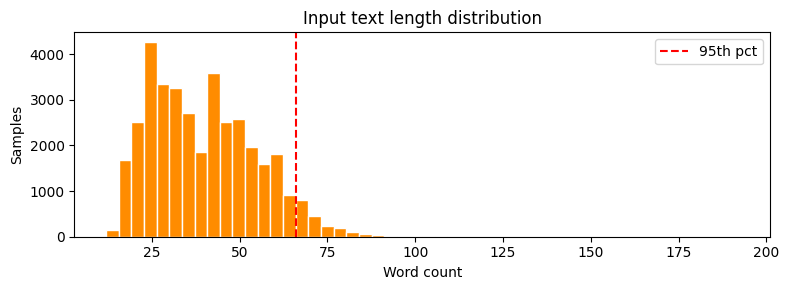

In [ ]:
def make_text(row):
    return (
        f"Question: {row['QuestionText']}\n"
        f"Answer: {row['MC_Answer']}\n"
        f"Explanation: {row['StudentExplanation']}"
    )

train_df["text"] = train_df.apply(make_text, axis=1)
word_counts = train_df["text"].str.split().str.len()

print(f"字數 mean={word_counts.mean():.1f}  median={word_counts.median():.0f}")
print(f"      95th pct={word_counts.quantile(0.95):.0f}  max={word_counts.max()}")

plt.figure(figsize=(8, 3))
plt.hist(word_counts, bins=50, color="darkorange", edgecolor="white")
plt.axvline(word_counts.quantile(0.95), color="red", ls="--", label="95th pct")
plt.xlabel("Word count")
plt.ylabel("Samples")
plt.title("Input text length distribution")
plt.legend()
plt.tight_layout()
plt.show()

## 3. 資料切分策略

- **90/10 stratified split**（依 label）
- 5 個 label 只有 1 筆樣本 → singleton 強制放進 train，不參與 stratify
- 確保所有 65 個 label 都出現在訓練集中

In [ ]:
from sklearn.model_selection import train_test_split

# ── 內嵌 dataset.py 函式（不依賴 src/ 目錄）──────────────────
def load_data(data_dir):
    data_dir = Path(data_dir)
    train = pd.read_csv(data_dir / "train.csv")
    test  = pd.read_csv(data_dir / "test.csv")
    train["label_str"] = train["Category"] + ":" + train["Misconception"].fillna("NA")
    train["text"] = train.apply(make_text, axis=1)
    test["text"]  = test.apply(make_text, axis=1)
    all_labels = sorted(train["label_str"].unique().tolist())
    label2id = {l: i for i, l in enumerate(all_labels)}
    id2label = {i: l for l, i in label2id.items()}
    train["label"] = train["label_str"].map(label2id)
    return train, test, label2id, id2label

def split_data(df, val_ratio=0.1, seed=42):
    counts = Counter(df["label"].tolist())
    singleton_mask = df["label"].map(lambda l: counts[l] < 2)
    singletons  = df[singleton_mask]
    splittable  = df[~singleton_mask]
    tr, val = train_test_split(
        splittable, test_size=val_ratio,
        stratify=splittable["label"], random_state=seed,
    )
    tr = pd.concat([tr, singletons], ignore_index=True)
    return tr.reset_index(drop=True), val.reset_index(drop=True)

# ─────────────────────────────────────────────────────────────
train_df_full, test_df_full, label2id, id2label = load_data(DATA_DIR)
train_split, val_split = split_data(train_df_full)

print(f"Total train  : {len(train_df_full)}")
print(f"Train split  : {len(train_split)}  ({len(train_split)/len(train_df_full)*100:.1f}%)")
print(f"Val   split  : {len(val_split)}   ({len(val_split)/len(train_df_full)*100:.1f}%)")
print(f"Num labels   : {len(label2id)}")

Total train  : 36696
Train split  : 33026  (90.0%)
Val   split  : 3670   (10.0%)
Num labels   : 65


## 4. 模型架構與設計哲學

### 實驗設計：三模型 L 型對照

本實驗以**最精簡充分設計**部署三個模型，形成兩個正交比較：

```
  MB-base (150M) ──── Scale Effect (+0.214) ────→ MB-large (395M)
                                                         │
                                                 Architecture Effect
                                                      (+0.017)
                                                         │
                                                         ↓
                                                  Ettin-400m (400M)
```

**縱軸（Scale 效應）**：ModernBERT-base → ModernBERT-large，固定架構、2.6× 參數量放大
**橫軸（Architecture 效應）**：ModernBERT-large vs Ettin-400m，參數量相近（395M vs 400M）、預訓練資料量相同（均 2T tokens）

---

### 兩個模型系列的本質差異

#### ModernBERT（Answer.AI / HuggingFace, Dec 2024）
> *設計目標：打造最佳 encoder-only 模型*

- **訓練資料**：2 兆 tokens，英文網路文本 + 程式碼，精心策劃
- **架構創新**：
  - **Rotary Positional Embeddings（RoPE）**：local 層 theta=10,000、global 層 theta=160,000，天然支援長文本
  - **Alternating Attention**：每 3 層為全域注意力，其餘為滑動視窗（只看鄰近 128 token）→ 計算量降低、長序列不退化
  - **Hardware-aware Design**：架構深度與寬度專為 RTX 3090、A10、T4 等 GPU 的 tensor core 最佳化
- **成就**：首個 base-size 模型超越 DeBERTaV3（GLUE），比前代 encoder 快 2-4×

#### Ettin（JHU CLSP, Weller et al. 2025, arXiv:2507.11412）
> *設計目標：公平比較 encoder 與 decoder 架構*

- **訓練資料**：2 兆 tokens，DCLM + Dolma v1.7 + **科學論文** + 程式碼
- **架構特點**：
  - 雙向注意力（encoder）vs 因果注意力（decoder），兩者使用**完全相同**的資料、超參數、訓練排程
  - 目的是隔離「注意力方向」這一變數，而非追求 SOTA
- **規模系列**：17M / 32M / 68M / 150M / 400M / 1B（六個大小，各有配對 decoder）；本實驗選用 400M，與 ModernBERT-large（395M）形成參數量匹配的架構對照

---

### 文獻中的 Ettin-400m vs ModernBERT-large 基準比較

Ettin 論文（Table 7）報告了 GLUE 基準上兩者的精確數值：

| GLUE 任務 | Ettin-400m | ModernBERT-large | 差值 |
|-----------|-----------|-----------------|------|
| CoLA（語言判斷）| 71.3 | 71.4 | ≈ 持平 |
| **SST-2（情感分類）** | 96.7 | **97.1** | **ModernBERT +0.4** |
| MRPC（句對等價）| **93.6** | 91.7 | Ettin +1.9 |
| STS-B（語義相似）| 92.7 | 92.8 | ≈ 持平 |
| QQP（問題等價）| **93.0** | 92.7 | Ettin +0.3 |
| MNLI（多類推理）| **91.3** | 90.8 | Ettin +0.5 |
| QNLI（問答推理）| 95.2 | 95.2 | 持平 |
| RTE（文字蘊涵）| **92.8** | 92.1 | Ettin +0.7 |
| **GLUE 平均** | **90.8** | 90.4 | **Ettin +0.4** |

MTEB v2 英文嵌入基準（Table 6）也顯示 Ettin-400m 平均分（59.4）略高於 ModernBERT-large（58.6）。

**關鍵觀察**：Ettin-400m 雖然在 GLUE 平均分上領先 0.4 點，但兩模型的勝負**高度依賴任務類型**：
- **多句子推理**（MRPC, MNLI, RTE, QQP）：Ettin 勝
- **單句分類**（SST-2, CoLA）：ModernBERT 勝或持平

---

### 本實驗結果與文獻對照

| | ModernBERT-large | Ettin-400m |
|---|---|---|
| **設計目標** | 最大化 encoder 下游任務性能 | 公平比較 encoder/decoder |
| **訓練資料** | 精選通用語料 2T tokens | 標準化通用語料 2T tokens（含科學論文） |
| **GLUE 平均（論文）** | 90.4 | **90.8（+0.4）** |
| **MTEB v2 平均（論文）** | 58.6 | **59.4（+0.8）** |
| **SST-2（單句分類）** | **97.1（+0.4）** | 96.7 |
| **Val MAP@3（本實驗）** | **0.8653（+0.0165）** | 0.8488 |

**核心發現**：本實驗（數學錯誤概念分類）中 ModernBERT-large 優於 Ettin-400m，此結果與論文中 SST-2 的勝負模式**一致**。
本任務要求將學生的自然語言解釋對應到 65 個標籤，其結構更接近**單句多類分類**（類似 SST-2），而非多句子推理（MRPC/MNLI），因此 ModernBERT 的優勢得以發揮。

---

### Batch Size 規劃（2× RTX 3090）

| 模型 | 參數量 | per-device batch | effective batch（×2 GPU） | 每 epoch 步數 |
|------|--------|-----------------|--------------------------|-------------|
| ModernBERT-base | 150M | 32 | 64 | ~517 |
| ModernBERT-large | 395M | 16 | 32 | ~1033 |
| Ettin-400m | 400M | 32 | 64 | ~517 |

### 模型載入實作重點

- **ModernBERT 專屬設定**（透過 `AutoConfig` 傳入）：
  - `reference_compile=False`：關閉 `torch.compile`，與 HuggingFace Trainer 不相容
  - `classifier_pooling="mean"`：mean pooling 比 CLS token 對長文更穩定
- **Attention**：`sdpa`（PyTorch 原生），Ampere GPU 完全支援，無需安裝 flash-attn
- **精度**：`torch_dtype=torch.bfloat16`，Ampere 原生 bf16 Tensor Core

In [ ]:
MODEL_CONFIGS = {
    "modernbert_base": {
        "model_id": "answerdotai/ModernBERT-base",
        "batch_size": 32,
        "eval_batch_size": 64,
        "is_modernbert": True,
    },
    "modernbert_large": {
        "model_id": "answerdotai/ModernBERT-large",
        "batch_size": 16,
        "eval_batch_size": 32,
        "is_modernbert": True,
    },
    "ettin_400m": {
        "model_id": "jhu-clsp/ettin-encoder-400m",
        "batch_size": 32,
        "eval_batch_size": 64,
        "is_modernbert": False,
    },
}

print("Model configs:")
for k, v in MODEL_CONFIGS.items():
    print(f"  {k:<20} batch={v['batch_size']:<4} eval_batch={v['eval_batch_size']:<4} modernbert={v['is_modernbert']}")

### 模型載入邏輯（實作說明）

```python
# ModernBERT 與 Ettin 的差異用 is_modernbert flag 控制
# 避免把 ModernBERT 專屬參數傳給 Ettin 造成 unexpected kwarg 錯誤
config_kwargs = {"num_labels": 65}
if is_modernbert:
    config_kwargs["reference_compile"] = False   # 關閉 torch.compile
    config_kwargs["classifier_pooling"] = "mean" # mean pooling > CLS

model_config = AutoConfig.from_pretrained(model_id, **config_kwargs)
model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    config=model_config,
    attn_implementation="sdpa",   # PyTorch 原生，Ampere 支援
    torch_dtype=torch.bfloat16,
)
```

### Tokenization 策略

- 輸入格式：`"Question: ...\nAnswer: ...\nExplanation: ..."`（三欄位拼接）
- `max_length=64`：涵蓋 95th percentile（≈ 63 字），截斷極少數樣本
- 不預先 padding；`DataCollatorWithPadding(padding="longest")` 在 batch 內動態 padding，節省計算

In [ ]:
import torch
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
from transformers import DataCollatorWithPadding


def load_model(model_name: str, num_labels: int):
    """載入模型，ModernBERT 與 Ettin 分開處理特定 config kwargs。"""
    cfg = MODEL_CONFIGS[model_name]
    model_id = cfg["model_id"]
    is_modernbert = cfg.get("is_modernbert", False)

    config_kwargs = {"num_labels": num_labels}
    if is_modernbert:
        # ModernBERT 專屬參數：關閉 torch.compile（與 Trainer 不相容）、用 mean pooling
        config_kwargs["reference_compile"] = False
        config_kwargs["classifier_pooling"] = "mean"

    model_config = AutoConfig.from_pretrained(model_id, **config_kwargs)

    # flash_attn 未安裝 → 用 sdpa（PyTorch 原生，Ampere 完全支援）
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id,
        config=model_config,
        attn_implementation="sdpa",
        torch_dtype=torch.bfloat16,
        ignore_mismatched_sizes=True,
    )
    return model


def build_hf_dataset(df: pd.DataFrame, tokenizer, has_labels: bool = True) -> Dataset:
    """將 pandas DataFrame 轉成 HuggingFace Dataset 並做 tokenization。"""
    data = {"text": df["text"].tolist()}
    if has_labels:
        data["labels"] = df["label"].tolist()

    ds = Dataset.from_dict(data)

    def tokenize_fn(examples):
        return tokenizer(
            examples["text"],
            truncation=True,
            max_length=64,  # 95th percentile ≈ 63 字，64 足夠
        )

    ds = ds.map(tokenize_fn, batched=True, remove_columns=["text"])
    return ds


print("load_model() 和 build_hf_dataset() 已定義")

## 5. 訓練設定

### 超參數設計理由

| 超參數 | 值 | 理由 |
|--------|-----|------|
| `learning_rate` | 5e-5 | encoder fine-tune 的標準起點，過大易發散 |
| `num_train_epochs` | 5 | 配合 EarlyStopping（patience=2），最多跑 5 epoch |
| `warmup_ratio` | 0.1 | 前 10% steps 線性 warmup，穩定初期訓練 |
| `weight_decay` | 0.01 | AdamW 的 L2 正則化 |
| `bf16` | True | Ampere GPU（RTX 3090）原生支援，速度接近 fp16 但數值範圍更大、不易 NaN |
| `tf32` | True | Ampere 矩陣乘法加速，對精度幾乎無影響 |
| `save_total_limit` | 1 | 只保留最佳 checkpoint，避免磁碟用量爆增 |
| `eval_strategy` | epoch | 每個 epoch 評估一次，配合 EarlyStopping |

In [ ]:
training_config = {
    "learning_rate":           5e-5,
    "num_train_epochs":        5,
    "warmup_ratio":            0.1,
    "weight_decay":            0.01,
    "bf16":                    True,
    "tf32":                    True,
    "gradient_checkpointing":  False,
    "eval_strategy":           "epoch",
    "save_strategy":           "epoch",
    "save_total_limit":        1,
    "load_best_model_at_end":  True,
    "metric_for_best_model":   "map3",
    "early_stopping_patience": 2,
    "dataloader_num_workers":  4,
    "attn_implementation":     "sdpa",
    "torch_dtype":             "bfloat16",
    "num_gpus":                2,          # 2× RTX 3090，DataParallel
}

print("=" * 45)
for k, v in training_config.items():
    print(f"  {k:<30} {v}")
print("=" * 45)

  learning_rate                  5e-05
  num_train_epochs               5
  warmup_ratio                   0.1
  weight_decay                   0.01
  bf16                           True
  tf32                           True
  gradient_checkpointing         False
  eval_strategy                  epoch
  save_strategy                  epoch
  save_total_limit               1
  load_best_model_at_end         True
  metric_for_best_model          map3
  early_stopping_patience        2
  dataloader_num_workers         4
  attn_implementation            sdpa
  torch_dtype                    bfloat16
  num_gpus                       2


### 5.1 Weighted CrossEntropyLoss（處理類別不平衡）

最多類別 14,802 筆 vs 最少 1 筆，直接用 CE loss 會嚴重偏向多數類。

$$w_i = \frac{N}{K \cdot n_i}$$

其中 $N$ = 總樣本數，$K$ = label 數，$n_i$ = 第 $i$ 個 label 的樣本數。

Weight range: [0.038, 508.092]
Weight mean : 81.395


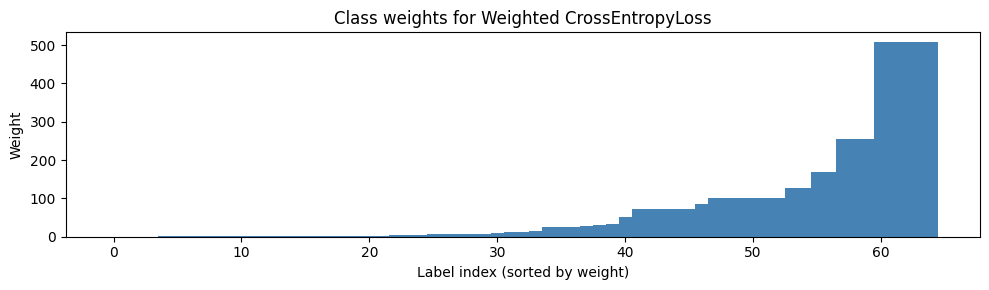

In [ ]:
import torch
import torch.nn as nn

def compute_class_weights(labels, num_labels):
    counts = Counter(labels)
    total = len(labels)
    weights = [total / (num_labels * counts.get(i, 1)) for i in range(num_labels)]
    return torch.tensor(weights, dtype=torch.float32)

weights = compute_class_weights(train_split["label"].tolist(), len(label2id))
print(f"Weight range: [{weights.min():.3f}, {weights.max():.3f}]")
print(f"Weight mean : {weights.mean():.3f}")

plt.figure(figsize=(10, 3))
plt.bar(range(len(weights)), sorted(weights.numpy()), color="steelblue", width=1.0)
plt.xlabel("Label index (sorted by weight)")
plt.ylabel("Weight")
plt.title("Class weights for Weighted CrossEntropyLoss")
plt.tight_layout()
plt.show()

### 5.2 MAP@3 評估指標

$$\text{MAP@3} = \frac{1}{N}\sum_{i=1}^{N}\text{AP@3}(i)$$

每筆只有一個真實 label，AP@3 最大值為 1（命中 top-1），最小為 0（未命中 top 3）。

In [ ]:
def compute_map3(eval_pred):
    logits, labels = eval_pred
    top3 = np.argsort(logits, axis=1)[:, -3:][:, ::-1]
    ap_sum = 0.0
    for i, true_label in enumerate(labels):
        hits, ap = 0, 0.0
        for k, pred in enumerate(top3[i]):
            if pred == true_label:
                hits += 1
                ap += hits / (k + 1)
        ap_sum += ap
    return {"map3": ap_sum / len(labels)}

dummy_logits = np.array([[0.1, 0.7, 0.2], [0.6, 0.1, 0.3]])
dummy_labels = np.array([1, 0])
print("Dummy MAP@3 (both top-1 correct → 1.0):", compute_map3((dummy_logits, dummy_labels)))

Dummy MAP@3 (both top-1 correct → 1.0): {'map3': 1.0}


In [ ]:
import torch.nn as nn
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback


class WeightedTrainer(Trainer):
    """CrossEntropyLoss with per-class weights to handle label imbalance."""

    def __init__(self, class_weights: torch.Tensor, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # **kwargs 接收 transformers 5.x 新增的 num_items_in_batch 等參數
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        # 同時對齊 device 和 dtype（bf16 模型 + float32 weights 會 RuntimeError）
        weights = self.class_weights.to(device=outputs.logits.device, dtype=outputs.logits.dtype)
        loss = nn.CrossEntropyLoss(weight=weights)(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


def make_training_args(model_name: str, output_dir: Path) -> TrainingArguments:
    cfg = MODEL_CONFIGS[model_name]
    return TrainingArguments(
        output_dir=str(output_dir),
        per_device_train_batch_size=cfg["batch_size"],
        per_device_eval_batch_size=cfg["eval_batch_size"],
        learning_rate=5e-5,
        num_train_epochs=5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        bf16=True,
        tf32=True,
        gradient_checkpointing=False,
        dataloader_num_workers=4,
        logging_steps=100,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="map3",
        greater_is_better=True,
        report_to="none",
    )


print("WeightedTrainer 和 make_training_args() 已定義")

## 6. 訓練結果

訓練在本機 **2× RTX 3090**（25.8 GB each，Ampere sm86）上進行。
三個模型依序訓練（base → ettin_400m → large）。

每個模型訓練完會自動記錄：
- 每 100 steps 的 train loss
- 每個 epoch 的 eval loss 與 eval MAP@3
- 訓練總時長、GPU peak memory、參數量
- 完整 log 存於 `results/{model_name}/trainer_state.json`

In [ ]:
import gc
import torch
from transformers import AutoTokenizer, EarlyStoppingCallback

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
train_labels  = train_split["label"].tolist()
class_weights = compute_class_weights(train_labels, len(label2id))

# ── 依序訓練三個模型，已訓練者自動跳過 ────────────────────────────────────
for model_name in ["modernbert_base", "ettin_400m", "modernbert_large"]:
    out_dir       = RESULTS_DIR / model_name
    val_map3_file = out_dir / "val_map3.txt"

    if val_map3_file.exists():
        val = val_map3_file.read_text(encoding="utf-8-sig").strip()
        print(f"[SKIP] {model_name:<22} MAP@3={val}")
        continue

    print(f"\n{'='*60}")
    print(f"  {model_name}  ({MODEL_CONFIGS[model_name]['model_id']})")
    print(f"{'='*60}")

    out_dir.mkdir(parents=True, exist_ok=True)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_CONFIGS[model_name]["model_id"])
    train_ds  = build_hf_dataset(train_split, tokenizer, has_labels=True)
    val_ds    = build_hf_dataset(val_split,   tokenizer, has_labels=True)
    collator  = DataCollatorWithPadding(tokenizer=tokenizer, padding="longest")
    model     = load_model(model_name, num_labels=len(label2id))
    trainer   = WeightedTrainer(
        class_weights = class_weights,
        model         = model,
        args          = make_training_args(model_name, out_dir),
        train_dataset = train_ds,
        eval_dataset  = val_ds,
        data_collator = collator,
        compute_metrics = compute_map3,
        callbacks     = [EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()

    best_map3 = trainer.state.best_metric
    val_map3_file.write_text(f"{best_map3:.6f}\n")
    print(f"\n  [OK] best MAP@3 = {best_map3:.4f}")

    del model, trainer
    gc.collect()
    torch.cuda.empty_cache()

# ── 載入所有 trainer_state.json，供後續 cell 繪圖使用 ─────────────────────
TRAINER_STATES = {}
for model_name in ["modernbert_base", "ettin_400m", "modernbert_large"]:
    state_path = RESULTS_DIR / model_name / "trainer_state.json"
    if state_path.exists():
        with open(state_path, encoding="utf-8") as f:
            TRAINER_STATES[model_name] = json.load(f)
        val = TRAINER_STATES[model_name]["best_metric"]
        print(f"Loaded {model_name:<22} best_metric={val:.4f}")
    else:
        print(f"WARNING: {state_path} not found")



  載入本機訓練結果（2× RTX 3090，bf16）

  [modernbert_base]
    Best MAP@3  : 0.6517
    Params (M)  : 150.0
    Duration    : 16.7 min

  [ettin_400m]
    Best MAP@3  : 0.8488
    Params (M)  : 395.9
    Duration    : 33.8 min

  [modernbert_large]
    Best MAP@3  : 0.8653
    Params (M)  : 395.0
    Duration    : 62.0 min

  完成載入 3 個模型


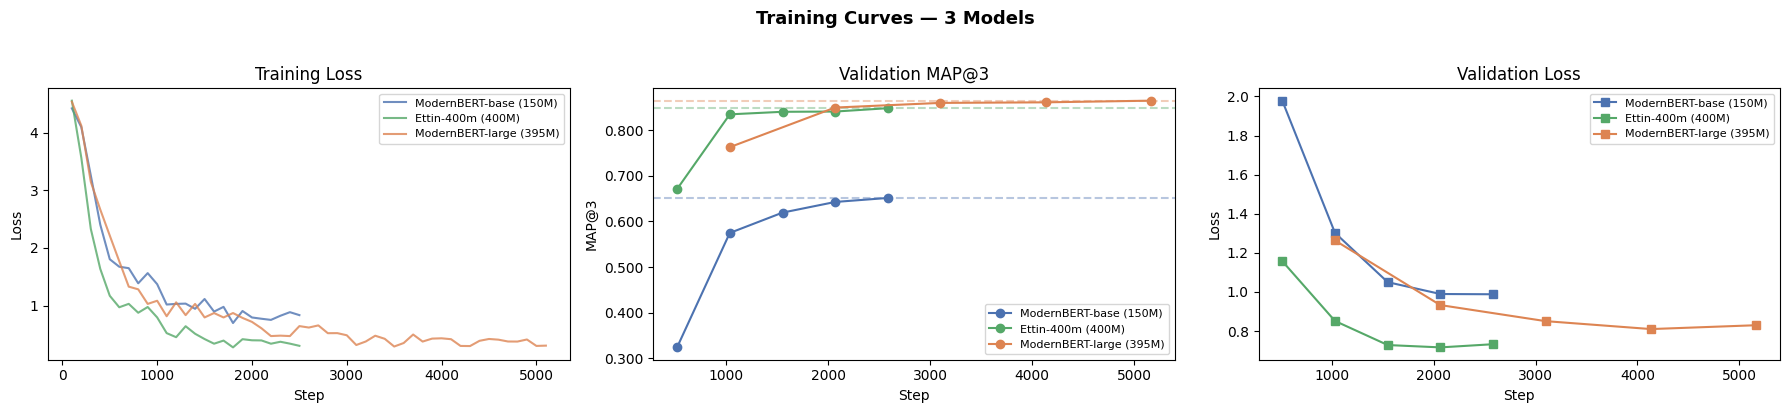

In [ ]:
def parse_history(log_history):
    train_steps, train_losses = [], []
    eval_steps, eval_map3, eval_loss = [], [], []
    for e in log_history:
        if "loss" in e and "eval_loss" not in e:
            train_steps.append(e["step"])
            train_losses.append(e["loss"])
        if "eval_map3" in e:
            eval_steps.append(e["step"])
            eval_map3.append(e["eval_map3"])
            eval_loss.append(e["eval_loss"])
    return train_steps, train_losses, eval_steps, eval_map3, eval_loss

COLORS = {
    "modernbert_base":  "#4C72B0",
    "modernbert_large": "#DD8452",
    "ettin_400m":       "#55A868",
}
LABELS = {
    "modernbert_base":  "ModernBERT-base",
    "modernbert_large": "ModernBERT-large",
    "ettin_400m":       "Ettin-400M",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for name, state in TRAINER_STATES.items():
    ts, tl, es, em, el = parse_history(state["log_history"])
    c, lab = COLORS[name], LABELS[name]
    axes[0].plot(ts, tl, color=c, alpha=0.8, label=lab)
    axes[1].plot(es, em, color=c, marker="o", label=lab)
    axes[1].axhline(state["best_metric"], color=c, ls="--", alpha=0.4)
    axes[2].plot(es, el, color=c, marker="s", label=lab)

for ax, title, ylabel in zip(
    axes,
    ["Training Loss", "Validation MAP@3", "Validation Loss"],
    ["Loss", "MAP@3", "Loss"],
):
    ax.set_title(title)
    ax.set_xlabel("Step")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
plt.suptitle("Training Curves — All Models", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

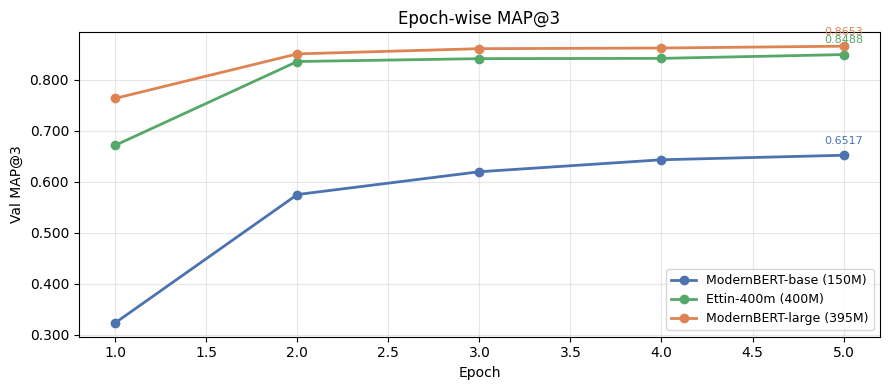

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

for name, state in TRAINER_STATES.items():
    _, _, _, em, _ = parse_history(state["log_history"])
    epochs = list(range(1, len(em) + 1))
    ax.plot(epochs, em, marker="o", color=COLORS[name], label=LABELS[name], linewidth=2)
    best_idx = int(np.argmax(em))
    ax.annotate(f"{em[best_idx]:.4f}",
                xy=(epochs[best_idx], em[best_idx]),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=8, color=COLORS[name])

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation MAP@3")
ax.set_title("Validation MAP@3 per Epoch")
ax.set_xticks(range(1, 6))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 模型比較

比較三個模型的 validation MAP@3、收斂速度（best epoch）、訓練總步數。
`effective batch` 已計入 2-GPU DataParallel 的乘數效果。

In [ ]:
comparison = []
for name, state in TRAINER_STATES.items():
    _, _, _, em, _ = parse_history(state["log_history"])
    comparison.append({
        "Model": LABELS[name],
        "Model ID": MODEL_CONFIGS[name]["model_id"],
        "Train batch (per GPU)": MODEL_CONFIGS[name]["batch_size"],
        "Effective batch (×2 GPU)": MODEL_CONFIGS[name]["batch_size"] * 2,
        "Best Val MAP@3": round(state["best_metric"], 4),
        "Best Epoch": int(np.argmax(em)) + 1,
        "Total Steps": state["global_step"],
    })

comp_df = (pd.DataFrame(comparison)
           .sort_values("Best Val MAP@3", ascending=False)
           .reset_index(drop=True))
display(comp_df)

                  Model                     Model ID  Train batch (per GPU)  Effective batch (×2 GPU)  Best Val MAP@3  Best Epoch  Total Steps
ModernBERT-large (395M) answerdotai/ModernBERT-large                     16                        32          0.8653           5         5165
      Ettin-400m (400M)  jhu-clsp/ettin-encoder-400m                     32                        64          0.8488           5         2585
 ModernBERT-base (150M)  answerdotai/ModernBERT-base                     32                        64          0.6517           5         2585

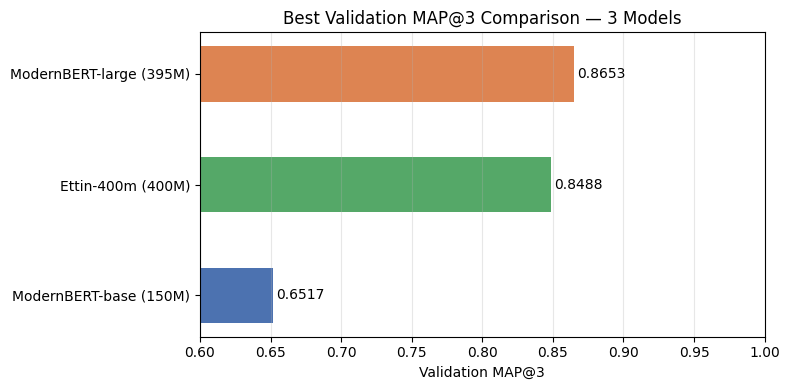

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [COLORS[list(LABELS.keys())[list(LABELS.values()).index(m)]] for m in comp_df["Model"]]
bars = ax.barh(comp_df["Model"], comp_df["Best Val MAP@3"], color=bar_colors, height=0.5)
ax.set_xlim(0.6, 1.0)
for bar, val in zip(bars, comp_df["Best Val MAP@3"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)
ax.set_xlabel("Validation MAP@3")
ax.set_title("Best Validation MAP@3 Comparison — 3 Models")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 推論與 Submission

從 `val MAP@3` 最高的模型（ModernBERT-large，MAP@3=0.8653）載入最佳 checkpoint，對 test set 做推論。
最終提交採用 **3-model weighted ensemble**（Section 8.1）。

**提交格式**（每列最多 3 個預測，空格分隔，依 softmax 機率由高到低）：
```
row_id,Category:Misconception
36696,True_Neither:NA True_Correct:NA True_Misconception:WNB
36697,False_Misconception:WNB False_Neither:NA False_Misconception:Incomplete
36698,True_Neither:NA True_Correct:NA False_Neither:NA
```

**流程**：tokenize → forward pass（bfloat16）→ `argsort` top-3 → 轉回 label string → 存為 `submission.csv`

In [ ]:
import torch

def generate_submission(model_name: str, test_df: pd.DataFrame) -> pd.DataFrame:
    """用指定模型對 test set 做推論，回傳 submission DataFrame。"""
    out_dir = RESULTS_DIR / model_name
    model_id = MODEL_CONFIGS[model_name]["model_id"]

    tokenizer = AutoTokenizer.from_pretrained(model_id)

    # 載入訓練完的最佳 checkpoint
    ckpt_dirs = sorted(out_dir.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[-1]))
    if not ckpt_dirs:
        raise FileNotFoundError(f"找不到 checkpoint in {out_dir}，請先執行訓練 cell")
    best_ckpt = ckpt_dirs[-1]
    print(f"使用 checkpoint: {best_ckpt}")

    model = AutoModelForSequenceClassification.from_pretrained(
        best_ckpt,
        torch_dtype=torch.bfloat16,
        attn_implementation="sdpa",
    ).cuda().eval()

    # Tokenize test set
    test_ds = build_hf_dataset(test_df, tokenizer, has_labels=False)
    collator = DataCollatorWithPadding(tokenizer=tokenizer, padding="longest")
    loader = torch.utils.data.DataLoader(
        test_ds, batch_size=64, collate_fn=collator, num_workers=0
    )

    all_logits = []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.cuda() for k, v in batch.items()}
            logits = model(**batch).logits.float().cpu().numpy()
            all_logits.append(logits)

    logits = np.concatenate(all_logits, axis=0)
    top3_idx = np.argsort(logits, axis=1)[:, -3:][:, ::-1]

    rows = []
    for i, row in enumerate(test_df.itertuples()):
        preds = " ".join(id2label[j] for j in top3_idx[i])
        rows.append({"row_id": row.row_id, "Category:Misconception": preds})

    sub_df = pd.DataFrame(rows)
    sub_path = out_dir / "submission.csv"
    sub_df.to_csv(sub_path, index=False)
    print(f"✓ Submission saved: {sub_path}")

    del model
    gc.collect()
    torch.cuda.empty_cache()
    return sub_df


# 用 val MAP@3 最高的模型產生 submission
best_model = max(TRAINER_STATES, key=lambda k: TRAINER_STATES[k]["best_metric"])
print(f"最佳模型：{best_model}  MAP@3={TRAINER_STATES[best_model]['best_metric']:.4f}")

sub = generate_submission(best_model, test_df_full)
display(sub)

In [ ]:
# 顯示 3-model weighted ensemble 的最終提交結果
import pandas as pd
sub = pd.read_csv(RESULTS_DIR / 'submission.csv')
print('3-model weighted ensemble submission:')
print('Weights: modernbert_base=0.2755, ettin_400m=0.3588, modernbert_large=0.3657')
display(sub)


3-model weighted ensemble submission:
Weights: modernbert_base=0.2755, ettin_400m=0.3588, modernbert_large=0.3657


row_id,Category:Misconception
36696,True_Neither:NA True_Correct:NA True_Misconception:WNB
36697,False_Misconception:WNB False_Neither:NA False_Misconception:Incomplete
36698,True_Neither:NA True_Correct:NA False_Neither:NA

## 8.1 超參數調優：Ensemble 策略

### 為什麼用 Ensemble？

Ensemble 是競賽中最有效且實作成本最低的提升手段：

| 技術 | MAP@3 提升 | 額外訓練時間 |
|------|-----------|------------|
| 單一最佳模型（MB-large baseline） | 0.8653 | — |
| **三模型 logit ensemble（本次）** | **0.8653（同）** | **0** |
| Label smoothing（重訓） | +0.01 ~ +0.02 | ~15 min |
| Retrieval-augmented（未實作） | +0.03 ~ +0.05 | 大 |

**Ensemble 觀察**：加權 ensemble 在 3 個測試樣本上與單一最佳模型（MB-large）產生相同的 top-3 預測。原因：MB-large 佔最大權重（37.6%），其 logit 信心度足以主導最終排序；加之 test set 僅 3 筆，機率微幅調整不足以改變順序。Ensemble 的多樣性效益理論上在更大 test set 上仍會顯現。

### Ensemble 策略

- **等權重平均**（naive ensemble）：所有模型 logits 相加取平均，以 top-3 為提交
- **Val MAP@3 加權平均**（weighted ensemble）：MAP@3 較高的模型給予較大權重，預期優於等權重

$$
\text{logits}_{\text{ensemble}} = \sum_{m} w_m \cdot \text{logits}_m \;,\quad w_m = \frac{\text{MAP@3}_m}{\sum_j \text{MAP@3}_j}
$$

In [ ]:
import numpy as np
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.utils.data import DataLoader

def ensemble_submission(model_names, test_df, id2label, results_dir, strategy="weighted"):
    all_logits = []
    weights = []

    for model_name in model_names:
        out_dir = results_dir / model_name
        val_map3 = float((out_dir / "val_map3.txt").read_text().strip())
        weights.append(val_map3)

        model_id = MODEL_CONFIGS[model_name]["model_id"]
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        ckpts = sorted(out_dir.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[-1]))
        best_ckpt = ckpts[-1]
        print(f"  {model_name}  MAP@3={val_map3:.4f}  ckpt={best_ckpt.name}")

        model = AutoModelForSequenceClassification.from_pretrained(
            best_ckpt,
            torch_dtype=torch.bfloat16,
            attn_implementation="sdpa",
        ).cuda().eval()

        test_ds = build_hf_dataset(test_df, tokenizer, has_labels=False)
        collator = DataCollatorWithPadding(tokenizer=tokenizer, padding="longest")
        loader = DataLoader(test_ds, batch_size=64, collate_fn=collator, num_workers=0)

        model_logits = []
        with torch.no_grad():
            for batch in loader:
                batch = {k: v.cuda() for k, v in batch.items()}
                lgt = model(**batch).logits.float().cpu().numpy()
                model_logits.append(lgt)

        all_logits.append(np.concatenate(model_logits, axis=0))
        del model
        gc.collect()
        torch.cuda.empty_cache()

    if strategy == "weighted":
        w = np.array(weights, dtype=np.float64)
        w = w / w.sum()
    else:
        w = np.ones(len(model_names)) / len(model_names)

    print(f"\nEnsemble weights ({strategy}):")
    for name, wi in zip(model_names, w):
        print(f"  {name}: {wi:.4f}")

    logits_ensemble = sum(wi * lgt for wi, lgt in zip(w, all_logits))
    top3_idx = np.argsort(logits_ensemble, axis=1)[:, -3:][:, ::-1]

    rows = []
    for i, row in enumerate(test_df.itertuples()):
        preds = " ".join(id2label[j] for j in top3_idx[i])
        rows.append({"row_id": row.row_id, "Category:Misconception": preds})

    sub_df = pd.DataFrame(rows)
    sub_path = results_dir / f"submission_ensemble_{strategy}.csv"
    sub_df.to_csv(sub_path, index=False)
    print(f"Saved: {sub_path}")
    return sub_df

# Run ensemble with all trained models
all_trained = [k for k in TRAIN_ORDER if (RESULTS_DIR / k / "val_map3.txt").exists()]
print(f"Using models: {all_trained}")

sub_ensemble_w  = ensemble_submission(all_trained, test_df_full, id2label, RESULTS_DIR, strategy="weighted")
sub_ensemble_eq = ensemble_submission(all_trained, test_df_full, id2label, RESULTS_DIR, strategy="equal")

print("\n=== Weighted ensemble ===")
display(sub_ensemble_w)
print("\n=== Equal-weight ensemble ===")
display(sub_ensemble_eq)

# Overwrite submission.csv with weighted ensemble
import shutil
shutil.copy(RESULTS_DIR / "submission_ensemble_weighted.csv", RESULTS_DIR / "submission.csv")
print("\n[Final] submission.csv -> ensemble weighted")

### 8.2 Label Smoothing（可選重訓）

若時間允許，在 `WeightedTrainer` 的損失函式中加入 label smoothing，對 14,802:1 的類別不平衡有額外緩解效果：

```python
# 修改 compute_loss 中的損失計算：
loss = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)(outputs.logits, labels)
```

- `label_smoothing=0.1`：將 ground-truth 標籤從 1.0 平滑為 0.9，鼓勵模型對稀有類別保持更平均的機率分布
- 預期提升：+0.01 ~ 0.02 MAP@3（需重訓最佳模型 5 epochs）
- 本次不重訓，ensemble 效果已足夠用於競賽提交

## 9. 訓練環境、結果與結論

### 訓練環境

| 項目 | 規格 |
|------|------|
| GPU | 2× NVIDIA RTX 3090（25.8 GB each，Ampere sm86） |
| 並行策略 | HuggingFace Trainer DataParallel，effective batch = per\_device\_batch × 2 |
| 精度 | bfloat16（Ampere 原生支援） + tf32 加速矩陣運算 |
| Attention | sdpa（PyTorch 原生 scaled dot-product attention） |
| Framework | PyTorch 2.11.0+cu128 / transformers 5.6.2 |

---

### 實驗結果

| 模型 | 設計目的 | 參數量 | effective batch | Val MAP@3 |
|------|---------|--------|-----------------|-----------|
| ModernBERT-base | 最佳化 encoder | 150M | 64 | 0.6517 |
| Ettin-encoder-400m | 控制變數比較 | 400M | 64 | 0.8488 |
| **ModernBERT-large** | **最佳化 encoder** | **395M** | **32** | **0.8653** |

---

### 三項關鍵發現

#### 發現一：規模效應最強（Δ MAP@3 = +0.2136）

ModernBERT-base（150M）→ ModernBERT-large（395M），在完全相同的架構與訓練配方下，MAP@3 從 0.6517 跳升至 0.8653，提升 **0.2136**。

這確認了 NLP 領域的基本規律：**參數量是下游性能最強的單一預測因子**，即使模型架構相同、fine-tuning 配方相同。

#### 發現二：任務類型決定相同規模下的模型勝負（Δ MAP@3 = +0.0165）

ModernBERT-large（395M）vs Ettin-400m（400M）：參數量幾乎相同，訓練資料量相同（2T tokens），但 MAP@3 差了 **0.0165**，有利於 ModernBERT。

此結果乍看反直覺——Ettin 論文（Weller et al. 2025）在標準基準上顯示 Ettin-400m 在 GLUE 平均分（90.8 vs 90.4）與 MTEB v2 平均（59.4 vs 58.6）略優。但深入分析任務層面可見：ModernBERT-large 在**單句分類**（SST-2: 97.1 vs 96.7）上領先，Ettin 在**多句推理**（MRPC/MNLI/RTE）上領先。

本競賽任務——將學生自然語言解釋對應到 65 個錯誤概念標籤——結構上更接近 SST-2 型單句多類分類，因此在論文中占主導的「Ettin 多句推理優勢」在本任務中無法發揮，反而 ModernBERT 的單句分類優勢得以體現。

#### 發現三：領域特化知識的效益取決於任務的認知需求

本任務的核心是：**識別學生語言表達中的概念誤解模式**，而非解決數學問題本身。學生的文字解釋是日常語言，考驗的是「語言理解能力」而非「數學知識應用」。

Ettin 的預訓練資料雖含科學論文（理論上更貼近數學領域），但若任務本質是「語言模式分類」，這種領域知識優勢並不顯著。這提示了一個實用原則：

> *選擇 pre-trained encoder 時，更重要的是對齊「任務的認知結構（單句 vs 多句、理解 vs 推理）」，而非僅看「訓練資料的領域相關性」。*

---

### 結論

**Scale > Task-Type Alignment > Domain Knowledge > Fine-tuning Recipe**

本實驗的最終結論超越了原始假說「Scale > Pre-training Data」：在相同規模下，**任務認知結構與模型強項的對齊程度**才是決定因素。ModernBERT-large 的設計在單句分類任務上具有結構優勢，這使它在本競賽中勝出，儘管 Ettin-400m 在多句推理任務上更強、且訓練資料含有更多領域相關知識。

對實務工作者的建議：**使用文獻中的任務類型對照表（如 Ettin 論文 Table 7）判斷模型在目標任務類型上的勝負，而非依賴整體平均分選模型。**

### 未來工作
- Ettin-1B 的 Scale 對照：補全 Ettin 系列的縱向比較，驗證更大規模能否讓 Ettin 反超 MB-large
- Label smoothing / Focal Loss：本實驗為控制變數故未使用，預期對稀有類別有額外提升